# SACDpy discrete timelapse z-stack reconstruction

This notebook reconstructs ONI folders of short SACD movies acquired at discrete time points and z planes. Each selected input folder is treated as one FOV, reconstructed into a `TZYX` timelapse z stack, and projected into a `TYX` z-MIP movie.

## 1. Setup

Run this notebook from the SACDpy package folder. The local `src/` folder is added to the Python path when the package is not installed.

In [1]:
from contextlib import nullcontext
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from rich.progress import BarColumn, MofNCompleteColumn, Progress, SpinnerColumn, TextColumn, TimeElapsedColumn, TimeRemainingColumn

repo = Path.cwd()
src = repo / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

from sacdpy import SACDParams, read_tiff_stack, reconstruct
from sacdpy.discrete_timelapse import (
    discover_folder_plans,
    infer_na,
    infer_pixel_nm,
    infer_time_interval_s,
    infer_z_spacing_um,
    output_paths_for_group,
    write_timelapse_tiff,
)

print(f"Working folder: {repo}")

Working folder: /Users/gmgao/GGscripts/GG-general-GuttmanLab/image_analysis/pipelines/SACDpy


## 2. Settings

Edit this cell for input FOV folders, output location, channel label, emission wavelength, and SACD parameters. `pixel_nm=None` and `na=None` read those values from the first input TIFF metadata when available.

In [2]:
input_folders = []  # set manually or run the folder picker cell below
folder_picker_start_dir = Path("/Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive")
glob_pattern = "*.tif"
recursive = True
output_dir = None  # None writes each FOV output next to that FOV folder
overwrite_outputs = False
require_complete_grid = True
show_progress = True

channel_name = "647"
wavelength_nm = 647.0

pixel_nm = None  # set a number to override TIFF metadata
fallback_pixel_nm = 117.0
na = None  # set a number to override TIFF metadata
fallback_na = 1.45

mag = 2
iter1 = 7
iter2 = 8
ac_order = 2
subfactor = 0.8

# Optional SACDm branches. Defaults reproduce the validated SACDm baseline.
ifbackground = False
backgroundfactor = 2.0
ifregistration = False
ifsparsedecon = False
fidelity = 100.0
tcontinuity = 0.1
sparsity = 1.0
sparse_iterations = 100

time_interval_source = "metadata"  # metadata, folder, nominal, or auto
nominal_time_interval_s = None  # used for time_interval_source="nominal" or metadata fallback

### 2a. Select input folders

Run this optional cell to choose one or more FOV folders with a popup window. On macOS, the native dialog allows selecting multiple folders in one step. If the popup is not available, edit `input_folders` manually in the settings cell.

In [3]:
def _select_input_folders_macos(start_dir):
    import subprocess

    start_dir = Path(start_dir).expanduser()
    if not start_dir.exists():
        start_dir = Path.home()
    start_posix = str(start_dir).replace('"', '\\"')
    script = f'''
set startFolder to POSIX file "{start_posix}" as alias
set chosenFolders to choose folder with prompt "Select one or more SACD FOV folders" default location startFolder with multiple selections allowed
set outputText to ""
repeat with oneFolder in chosenFolders
    set outputText to outputText & POSIX path of oneFolder & linefeed
end repeat
return outputText
'''
    result = subprocess.run(["osascript", "-e", script], check=True, capture_output=True, text=True)
    return [Path(line) for line in result.stdout.splitlines() if line.strip()]


def _select_input_folders_tk(start_dir):
    import tkinter as tk
    from tkinter import filedialog, messagebox

    start_dir = Path(start_dir).expanduser()
    parent = filedialog.askdirectory(
        title="Choose a parent folder containing FOV folders",
        initialdir=str(start_dir if start_dir.exists() else Path.home()),
    )
    if not parent:
        return []
    parent = Path(parent)
    candidates = sorted(path for path in parent.iterdir() if path.is_dir())
    selected = []

    root = tk.Tk()
    root.title("Select SACD FOV folders from parent")
    root.geometry("900x420")

    label = tk.Label(root, text=f"Select one or more FOV folders inside: {parent}")
    label.pack(anchor="w", padx=10, pady=(10, 2))

    frame = tk.Frame(root)
    frame.pack(fill="both", expand=True, padx=10, pady=5)

    scrollbar = tk.Scrollbar(frame)
    scrollbar.pack(side="right", fill="y")
    listbox = tk.Listbox(frame, selectmode="extended", yscrollcommand=scrollbar.set)
    listbox.pack(side="left", fill="both", expand=True)
    scrollbar.config(command=listbox.yview)

    def refresh():
        listbox.delete(0, tk.END)
        for path in candidates:
            listbox.insert(tk.END, str(path))

    def select_all():
        listbox.select_set(0, tk.END)

    def done():
        selected[:] = [candidates[index] for index in listbox.curselection()]
        if not selected:
            messagebox.showwarning("No folders selected", "Select at least one FOV folder or close and edit input_folders manually.")
            return
        root.quit()
        root.destroy()

    def cancel():
        selected.clear()
        root.quit()
        root.destroy()

    buttons = tk.Frame(root)
    buttons.pack(fill="x", padx=10, pady=10)
    tk.Button(buttons, text="Select All", command=select_all).pack(side="left", padx=(0, 6))
    tk.Button(buttons, text="Cancel", command=cancel).pack(side="left", padx=6)
    tk.Button(buttons, text="Done", command=done).pack(side="right")

    refresh()
    root.mainloop()
    return selected


def select_input_folders(start_dir):
    if sys.platform == "darwin":
        try:
            selected = _select_input_folders_macos(start_dir)
            if selected:
                return selected
        except Exception as exc:
            print(f"macOS multi-folder picker failed; using Tk fallback. ({exc})")
    return _select_input_folders_tk(start_dir)


input_folders = select_input_folders(folder_picker_start_dir)
print("Selected input folders:")
for folder in input_folders:
    print(f"- {folder}")

Selected input folders:
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/undiff-SPEN_JFX650-200ms15f_30s-FOV-3
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/undiff-SPEN_JFX650-200ms15f_30s-FOV-2
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/undiff-SPEN_JFX650-200ms15f_30s-FOV-1
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/undiff-SPEN_JFX650-200ms15f_30s-FOV
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Dox-SPEN_JFX650-200ms15f_30s-FOV-2
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Dox-SPEN_JFX650-200ms15f_30s-FOV-1
- /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Dox-SPEN_JFX650-200ms15f_30s-FOV


## 3. Preview inputs and metadata

Run this cell first to confirm the notebook found the expected FOV folders, files, time points, z planes, and metadata-derived spacing.

In [4]:
if not input_folders:
    raise ValueError("input_folders is empty. Add at least one FOV folder in the settings or folder picker cell.")

folder_plans = discover_folder_plans(
    input_folders,
    glob_pattern=glob_pattern,
    channel_name=channel_name,
    recursive=recursive,
    output_dir=output_dir,
)
if not any(plan.files for plan in folder_plans):
    raise FileNotFoundError(f"No ONI timelapse-z TIFF files found in selected folders with pattern {glob_pattern!r}")

total_input_movies = sum(len(plan.files) for plan in folder_plans)
total_groups = sum(len(plan.groups) for plan in folder_plans)
print(f"Selected {len(folder_plans)} FOV folder(s). Found {total_input_movies} input TIFF movie(s) in {total_groups} group(s).")

for plan in folder_plans:
    print(f"\nFOV folder: {plan.input_folder}")
    print(f"Output folder: {plan.output_dir}")
    if not plan.files:
        print("  No matching ONI timelapse-z TIFF files found.")
        continue
    for group in plan.groups:
        first_file = next(iter(group.files.values()))
        resolved_pixel_nm = pixel_nm if pixel_nm is not None else infer_pixel_nm(first_file, fallback_pixel_nm)
        resolved_na = na if na is not None else infer_na(first_file, fallback_na)
        z_spacing_um = infer_z_spacing_um(group)
        time_interval_s = infer_time_interval_s(
            group,
            source=time_interval_source,
            nominal_time_interval_s=nominal_time_interval_s,
        )
        stack_output, mip_output = output_paths_for_group(group, plan.output_dir)
        print("-", group.prefix, f"channel={group.channel}", f"posXY={group.pos_xy}")
        print(f"  files={len(group.files)} | time points={group.time_indices} | z planes={group.z_indices}")
        print(f"  complete={group.is_complete} | missing={group.missing_entries[:10]}")
        print(f"  pixel_nm={resolved_pixel_nm} | effective_output_pixel_um={resolved_pixel_nm / 1000 / mag if resolved_pixel_nm else None}")
        print(f"  na={resolved_na} | z_spacing_um={z_spacing_um} | time_interval_s={time_interval_s}")
        print(f"  outputs: {stack_output.name}, {mip_output.name}")

Selected 8 FOV folder(s). Found 600 input TIFF movie(s) in 8 group(s).

FOV folder: /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV
Output folder: /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV
- ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV channel=647 posXY=0
  files=75 | time points=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14) | z planes=(0, 1, 2, 3, 4)
  complete=True | missing=()
  pixel_nm=116.99999868869781 | effective_output_pixel_um=0.05849999934434891
  na=1.4500000476837158 | z_spacing_um=0.7500589999999647 | time_interval_s=36.201289
  outputs: ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-TZYX.tif, ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-MIP-TYX.tif

FOV folder: /Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/undiff-SPEN_JFX650-200ms15f_30

## 4. Run reconstruction

This cell writes one `TZYX` SACD z-stack timelapse and one `TYX` z-MIP timelapse per detected group. A progress bar advances once for each short TIFF movie.

In [5]:
results = []
total_movies_to_process = sum(len(group.files) for plan in folder_plans for group in plan.groups)

progress_context = nullcontext(None)
if show_progress:
    progress_context = Progress(
        SpinnerColumn(),
        TextColumn("[progress.description]{task.description}"),
        BarColumn(),
        MofNCompleteColumn(),
        TimeElapsedColumn(),
        TimeRemainingColumn(),
    )

with progress_context as progress:
    task_id = None
    if progress is not None:
        task_id = progress.add_task("SACD timelapse", total=total_movies_to_process)

    for plan in folder_plans:
        plan.output_dir.mkdir(parents=True, exist_ok=True)
        for group in plan.groups:
            if require_complete_grid and not group.is_complete:
                raise ValueError(f"Group {group.prefix} posXY{group.pos_xy} is missing time/z files: {group.missing_entries}")

            first_file = next(iter(group.files.values()))
            resolved_pixel_nm = pixel_nm if pixel_nm is not None else infer_pixel_nm(first_file, fallback_pixel_nm)
            resolved_na = na if na is not None else infer_na(first_file, fallback_na)
            if resolved_pixel_nm is None or resolved_na is None:
                raise ValueError("pixel_nm and na must be provided or readable from TIFF metadata.")

            params = SACDParams(
                pixel_nm=float(resolved_pixel_nm),
                wavelength_nm=float(wavelength_nm),
                na=float(resolved_na),
                mag=mag,
                iter1=iter1,
                iter2=iter2,
                ac_order=ac_order,
                subfactor=subfactor,
                frames_per_sacd=None,
                ifbackground=ifbackground,
                backgroundfactor=backgroundfactor,
                ifregistration=ifregistration,
                ifsparsedecon=ifsparsedecon,
                fidelity=fidelity,
                tcontinuity=tcontinuity,
                sparsity=sparsity,
                sparse_iterations=sparse_iterations,
            )
            z_spacing_um = infer_z_spacing_um(group)
            time_interval_s = infer_time_interval_s(
                group,
                source=time_interval_source,
                nominal_time_interval_s=nominal_time_interval_s,
            )
            output_pixel_um = float(resolved_pixel_nm) / 1000.0 / mag
            stack_output, mip_output = output_paths_for_group(group, plan.output_dir)

            existing = [path for path in (stack_output, mip_output) if path.exists()]
            if existing and not overwrite_outputs:
                if len(existing) == 2:
                    print(f"Skipped {group.prefix} posXY{group.pos_xy}: outputs already exist")
                    if progress is not None and task_id is not None:
                        progress.advance(task_id, len(group.files))
                    results.append({"folder": plan.input_folder, "group": group, "stack_output": stack_output, "mip_output": mip_output, "status": "skipped_existing"})
                    continue
                raise FileExistsError(f"Only some outputs already exist: {existing}. Set overwrite_outputs=True or remove partial outputs.")

            sacd_times = []
            for time_index in group.time_indices:
                sacd_z = []
                for z_index in group.z_indices:
                    input_file = group.files[(time_index, z_index)]
                    if progress is not None and task_id is not None:
                        progress.update(task_id, description=f"{plan.input_folder.name} t{time_index} z{z_index}")
                    raw = read_tiff_stack(input_file)
                    sacd = reconstruct(raw, params)
                    if sacd.ndim != 2:
                        raise ValueError(f"Expected one SACD image from {input_file.name}, got shape {sacd.shape}")
                    sacd_z.append(sacd)
                    if progress is not None and task_id is not None:
                        progress.advance(task_id)
                sacd_times.append(np.stack(sacd_z, axis=0))

            sacd_tzyx = np.stack(sacd_times, axis=0).astype(np.float32, copy=False)
            sacd_mip_tyx = np.max(sacd_tzyx, axis=1).astype(np.float32, copy=False)

            write_timelapse_tiff(
                stack_output,
                sacd_tzyx,
                axes="TZYX",
                pixel_size_um=output_pixel_um,
                z_spacing_um=z_spacing_um,
                time_interval_s=time_interval_s,
            )
            write_timelapse_tiff(
                mip_output,
                sacd_mip_tyx,
                axes="TYX",
                pixel_size_um=output_pixel_um,
                time_interval_s=time_interval_s,
            )
            print(f"Wrote {stack_output.name} {sacd_tzyx.shape} and {mip_output.name} {sacd_mip_tyx.shape}")
            results.append({"folder": plan.input_folder, "group": group, "stack_output": stack_output, "mip_output": mip_output, "status": "written"})

results

Output()

Wrote ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) and 
ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-3-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) 
and ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-3-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-2-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) 
and ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-2-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-1-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) 
and ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-1-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) and
ONI-gmgao-SPEN_SACDlive_undiff-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_Dox-SPEN_JFX650-200ms15f_30s-FOV-2-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) and 
ONI-gmgao-SPEN_SACDlive_Dox-SPEN_JFX650-200ms15f_30s-FOV-2-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_Dox-SPEN_JFX650-200ms15f_30s-FOV-1-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) and 
ONI-gmgao-SPEN_SACDlive_Dox-SPEN_JFX650-200ms15f_30s-FOV-1-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

Wrote ONI-gmgao-SPEN_SACDlive_Dox-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-TZYX.tif (15, 5, 1368, 856) and 
ONI-gmgao-SPEN_SACDlive_Dox-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-MIP-TYX.tif (15, 1368, 856)

[{'folder': PosixPath('/Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV'),
  'group': TimelapseGroup(prefix='ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV', channel='647', pos_xy=0, files={(0, 0): PosixPath('/Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV/pos_0/ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV_posXY0_channels_t0_posZ0.tif'), (0, 1): PosixPath('/Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV/pos_0/ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV_posXY0_channels_t0_posZ1.tif'), (0, 2): PosixPath('/Volumes/guttman/primarydata/imaging_rawdata/20260529_ONI-gmgao-SPEN_SACDlive/Aux-SPEN_JFX650-200ms15f_30s-FOV/pos_0/ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV_posXY0_channels_t0_posZ2.tif'), (0, 3): PosixPath('/Volumes/guttman/primarydata/imaging_rawdata

## 5. Preview first result

This cell displays the first reconstructed time point across z planes plus the matching MIP frame.

Previewing ONI-gmgao-SPEN_SACDlive_Aux-SPEN_JFX650-200ms15f_30s-FOV-SACDpy-647-posXY0-TZYX.tif: stack (15, 5, 1368, 856), MIP (15, 1368, 856)


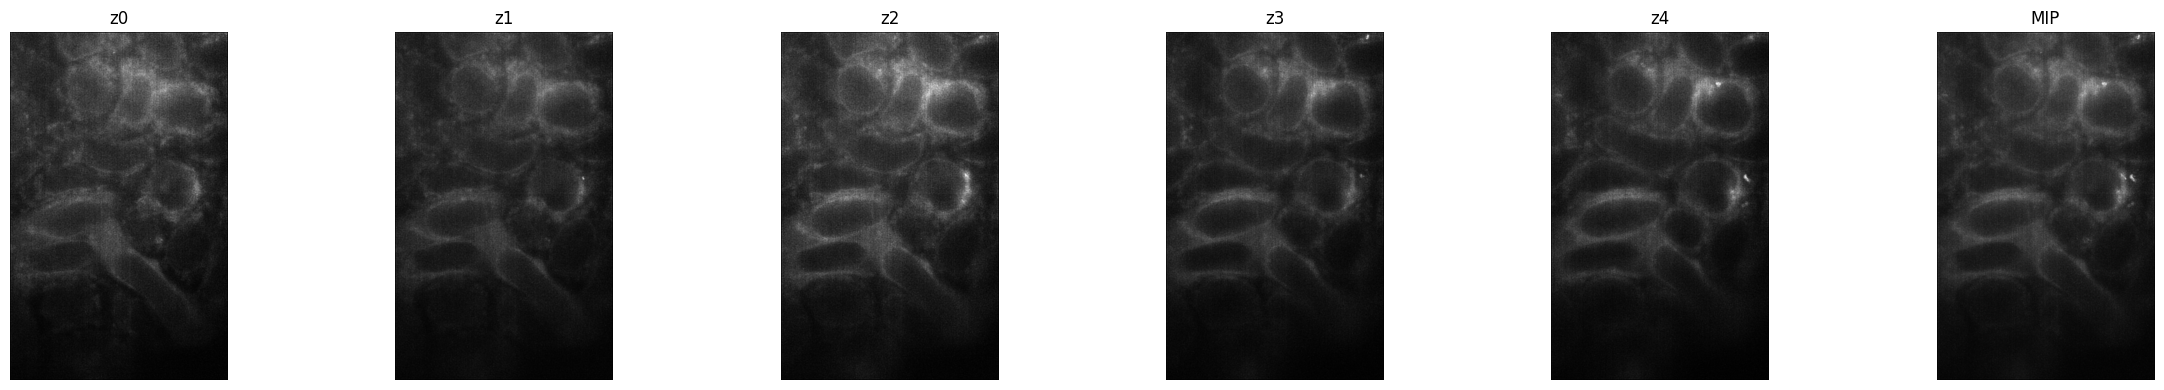

In [6]:
written_or_existing = [item for item in results if item["status"] in {"written", "skipped_existing"}]
if not written_or_existing:
    raise RuntimeError("No outputs are available to preview.")

preview = written_or_existing[0]
stack = read_tiff_stack(preview["stack_output"])
mip = read_tiff_stack(preview["mip_output"])

first_t_stack = stack[0]
first_t_mip = mip[0]
n_z = first_t_stack.shape[0]
fig, axes = plt.subplots(1, n_z + 1, figsize=(4 * (n_z + 1), 4), squeeze=False)

for z_index, ax in enumerate(axes.ravel()[:n_z]):
    ax.imshow(first_t_stack[z_index], cmap="gray")
    ax.set_title(f"z{z_index}")
    ax.axis("off")

axes.ravel()[-1].imshow(first_t_mip, cmap="gray")
axes.ravel()[-1].set_title("MIP")
axes.ravel()[-1].axis("off")
plt.tight_layout()
print(f"Previewing {preview['stack_output'].name}: stack {stack.shape}, MIP {mip.shape}")